<a href="https://colab.research.google.com/github/kimmich001207-art/Kimmich/blob/main/hotel_booking_predict.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_curve, auc, roc_auc_score, classification_report, confusion_matrix, make_scorer, ConfusionMatrixDisplay, precision_score, recall_score, accuracy_score


In [6]:
df_raw=pd.read_csv('hotel_booking_cleaned (1).csv')
df=df_raw.copy().drop(columns=['name','email','agent','company','country'])

df.iloc[:,:15].head(10)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,adults,children,babies,meal,market_segment,distribution_channel,is_repeated_guest,previous_cancellations
0,Resort Hotel,0,342,2015,July,27,1,2,0,0,BB,Direct,Direct,0,0
1,Resort Hotel,0,737,2015,July,27,1,2,0,0,BB,Direct,Direct,0,0
2,Resort Hotel,0,7,2015,July,27,1,1,0,0,BB,Direct,Direct,0,0
3,Resort Hotel,0,13,2015,July,27,1,1,0,0,BB,Corporate,Corporate,0,0
4,Resort Hotel,0,14,2015,July,27,1,2,0,0,BB,Online TA,TA/TO,0,0
5,Resort Hotel,0,14,2015,July,27,1,2,0,0,BB,Online TA,TA/TO,0,0
6,Resort Hotel,0,0,2015,July,27,1,2,0,0,BB,Direct,Direct,0,0
7,Resort Hotel,0,9,2015,July,27,1,2,0,0,FB,Direct,Direct,0,0
8,Resort Hotel,1,85,2015,July,27,1,2,0,0,BB,Online TA,TA/TO,0,0
9,Resort Hotel,1,75,2015,July,27,1,2,0,0,HB,Offline TA/TO,TA/TO,0,0


In [7]:
df.iloc[:,15:].head(10)

,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,arrival_date,weekday,tot_visitor,tot_stay
0,0,C,C,3,No Deposit,0,Transient,0.0,0,0,Check-Out,7/1/2015,7/1/2015,Wednesday,2,0
1,0,C,C,4,No Deposit,0,Transient,0.0,0,0,Check-Out,7/1/2015,7/1/2015,Wednesday,2,0
2,0,A,C,0,No Deposit,0,Transient,75.0,0,0,Check-Out,7/2/2015,7/1/2015,Wednesday,1,1
3,0,A,A,0,No Deposit,0,Transient,75.0,0,0,Check-Out,7/2/2015,7/1/2015,Wednesday,1,1
4,0,A,A,0,No Deposit,0,Transient,98.0,0,1,Check-Out,7/3/2015,7/1/2015,Wednesday,2,2
5,0,A,A,0,No Deposit,0,Transient,98.0,0,1,Check-Out,7/3/2015,7/1/2015,Wednesday,2,2
6,0,C,C,0,No Deposit,0,Transient,107.0,0,0,Check-Out,7/3/2015,7/1/2015,Wednesday,2,2
7,0,C,C,0,No Deposit,0,Transient,103.0,0,1,Check-Out,7/3/2015,7/1/2015,Wednesday,2,2
8,0,A,A,0,No Deposit,0,Transient,82.0,0,1,Canceled,5/6/2015,7/1/2015,Wednesday,2,3
9,0,D,D,0,No Deposit,0,Transient,105.5,0,0,Canceled,4/22/2015,7/1/2015,Wednesday,2,3


In [8]:
# 1. Map months to numbers (Preserves order)
month_map = {
    'January': 1, 'February': 2, 'March': 3, 'April': 4, 'May': 5, 'June': 6,
    'July': 7, 'August': 8, 'September': 9, 'October': 10, 'November': 11, 'December': 12
}
df['arrival_date_month_num'] = df['arrival_date_month'].map(month_map)


In [9]:
# Create a new feature: 0 if assigned room matches reserved room, 1 otherwise (usually an upgrade)
# This is often a strong indicator of customer satisfaction or overbooking situations
df['room_changed'] = (df['reserved_room_type'] != df['assigned_room_type']).astype(int)

In [10]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,adults,children,babies,...,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,arrival_date,weekday,tot_visitor,tot_stay,arrival_date_month_num,room_changed
0,Resort Hotel,0,342,2015,July,27,1,2,0,0,...,0,0,Check-Out,7/1/2015,7/1/2015,Wednesday,2,0,7,0
1,Resort Hotel,0,737,2015,July,27,1,2,0,0,...,0,0,Check-Out,7/1/2015,7/1/2015,Wednesday,2,0,7,0
2,Resort Hotel,0,7,2015,July,27,1,1,0,0,...,0,0,Check-Out,7/2/2015,7/1/2015,Wednesday,1,1,7,1
3,Resort Hotel,0,13,2015,July,27,1,1,0,0,...,0,0,Check-Out,7/2/2015,7/1/2015,Wednesday,1,1,7,0
4,Resort Hotel,0,14,2015,July,27,1,2,0,0,...,0,1,Check-Out,7/3/2015,7/1/2015,Wednesday,2,2,7,0


In [11]:
X=df.drop(columns=['is_canceled','reservation_status','reservation_status_date','arrival_date','reserved_room_type','assigned_room_type','arrival_date_month'])
y = df['is_canceled']

categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
X_encoded = pd.get_dummies(X, columns=categorical_cols)


# Decision Tree

In [12]:
# 4. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# 5. Train Decision Tree
# We limit max_depth to avoid overfitting and make the tree readable
tree_model = DecisionTreeClassifier(max_depth=5, random_state=42)
tree_model.fit(X_train, y_train)

# 6. Evaluation
y_pred_dt = tree_model.predict(X_test)
print("Decision Tree Performance:")
print(classification_report(y_test, y_pred_dt))

Decision Tree Performance:
              precision    recall  f1-score   support

           0       0.73      1.00      0.84     14973
           1       0.99      0.37      0.54      8902

    accuracy                           0.76     23875
   macro avg       0.86      0.68      0.69     23875
weighted avg       0.83      0.76      0.73     23875



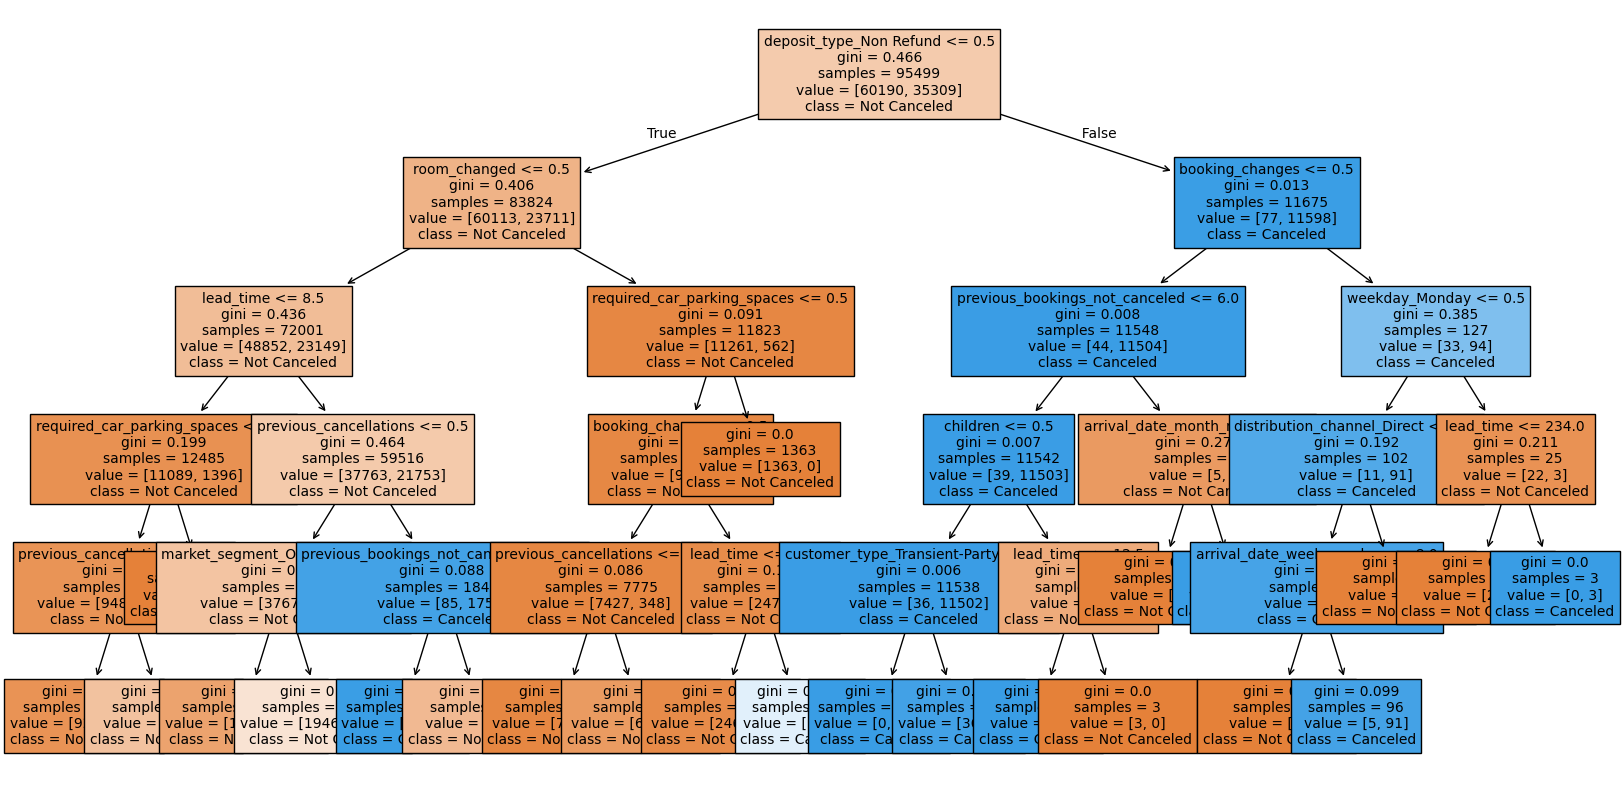

In [13]:
# 7. Visualize the Tree (The cool part of Decision Trees!)
plt.figure(figsize=(20,10))
plot_tree(tree_model,
          feature_names=X_encoded.columns,
          class_names=['Not Canceled', 'Canceled'],
          filled=True,
          fontsize=10)
plt.show()

# Random Forest

In [14]:
# 4. Hyperparameter Tuning with GridSearchCV
# Define the parameter grid to explore
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [20, 30, None],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt']
}

# Initialize the Random Forest model
rf = RandomForestClassifier(random_state=42)

# Set up Grid Search with 3-fold cross-validation
grid_search_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_rf,
    cv=3,
    n_jobs=-1,
    scoring='accuracy',
    verbose=2
)

# Fit the model (This may take a few minutes)
grid_search_rf.fit(X_train, y_train)

# 5. Output Results
print(f"Best Parameters: {grid_search_rf.best_params_}")
print(f"Best Cross-Validation Score: {grid_search_rf.best_score_:.4f}")

# Evaluate the best model on the test set
best_model_rf = grid_search_rf.best_estimator_
y_pred_rf = best_model_rf.predict(X_test)

print("\nModel Performance on Test Set:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

# 6. Feature Importance of the Optimized Model
importances = pd.Series(best_model_rf.feature_importances_, index=X_encoded.columns)
print("\nTop 10 Most Important Features (Optimized):")
print(importances.sort_values(ascending=False).head(10))

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best Parameters: {'max_depth': 30, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 100}
Best Cross-Validation Score: 0.8656

Model Performance on Test Set:
Accuracy: 0.8677

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.93      0.90     14973
           1       0.87      0.76      0.81      8902

    accuracy                           0.87     23875
   macro avg       0.87      0.85      0.85     23875
weighted avg       0.87      0.87      0.87     23875


Top 10 Most Important Features (Optimized):
lead_time                    0.126818
deposit_type_Non Refund      0.100504
adr                          0.085733
deposit_type_No Deposit      0.071531
total_of_special_requests    0.064797
arrival_date_day_of_month    0.054161
arrival_date_week_number     0.053222
tot_stay                     0.046067
previous_cancellations       0.041290
room_changed

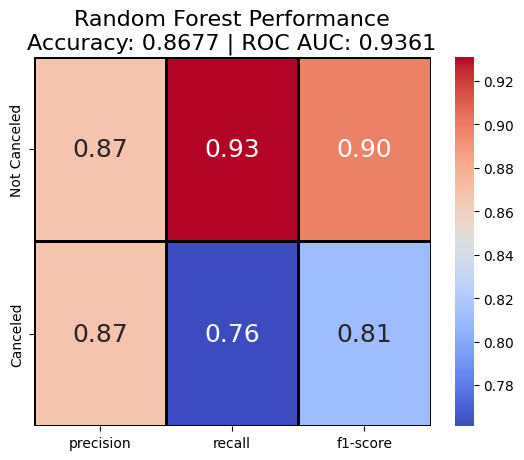

In [34]:
y_prob_rf = best_model_rf.predict_proba(X_test)[:, 1]
report_rf = classification_report(y_test, y_pred_rf, output_dict=True)
df_report_rf = pd.DataFrame(report_rf).T

metrics_df = df_report_rf.loc[['0','1'], ['precision','recall','f1-score']]
metrics_df.index = ["Not Canceled", "Canceled"]

plt.figure()
sns.heatmap(metrics_df, annot=True,cmap = "coolwarm", fmt=".2f", annot_kws={"size":18},linewidths=2,
    linecolor="black", )

plt.title(
    f"Random Forest Performance\n"
    f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f} | "
    f"ROC AUC: {roc_auc_score(y_test, y_prob_rf):.4f}",
    fontsize=16
)
plt.show()

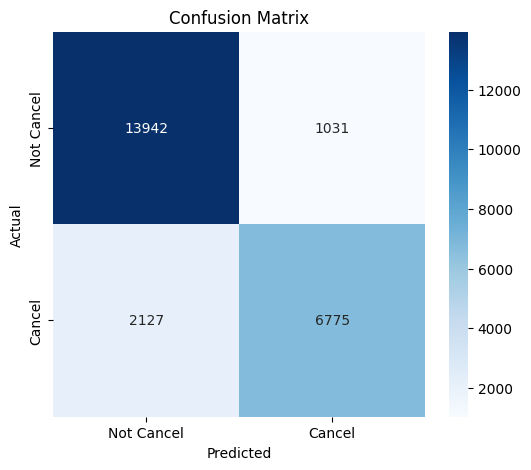

In [15]:
cm_rf=confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))
sns.heatmap(cm_rf,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Not Cancel', 'Cancel'],
            yticklabels=['Not Cancel', 'Cancel'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

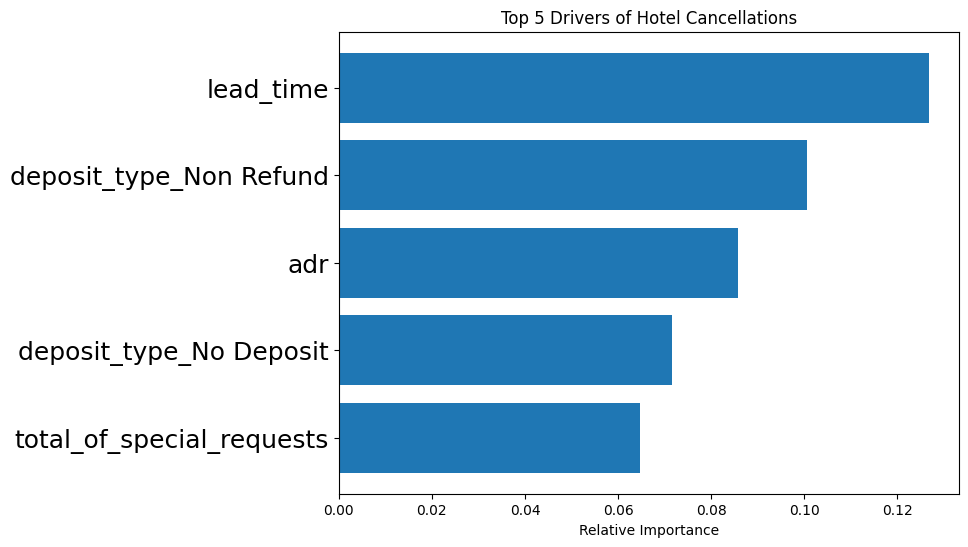

In [54]:
# Get feature importance from the best XGBoost model
importances_rf = best_model_rf.feature_importances_
feat_names = X_encoded.columns
indices = np.argsort(importances_rf)[-5:] # Top 10 features

plt.figure(figsize=(8, 6))
plt.title('Top 5 Drivers of Hotel Cancellations')
plt.barh(range(len(indices)), importances_rf[indices], align='center')
plt.yticks(range(len(indices)), [feat_names[i] for i in indices],fontsize=18)
plt.xlabel('Relative Importance')
plt.show()

# XGBoost

In [16]:
#Calculate the ratio
num_zeros = len(df[df['is_canceled'] == 0])
num_ones = len(df[df['is_canceled'] == 1])
ratio = num_zeros / num_ones

print(f"Negative samples: {num_zeros}")
print(f"Positive samples: {num_ones}")
print(f"Calculated scale_pos_weight: {ratio:.2f}")

Negative samples: 75163
Positive samples: 44211
Calculated scale_pos_weight: 1.70


In [24]:
# 3. Define the parameter grid
# Don't make this too large at first, or it will take hours!
param_grid_xgb = {
    'n_estimators': [100, 200],           # Number of trees
    'max_depth': [3, 6, 9],               # Depth of each tree
    'learning_rate': [0.01, 0.1],         # Step size shrinkage
    'subsample': [0.8, 1.0]               # % of data used per tree
}

# 4. Initialize the classifier
xgb = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

# 5. Initialize GridSearchCV
# cv=3 means 3-fold cross-validation
# scoring='roc_auc' is better than 'accuracy' for imbalanced data
grid_search_xgb = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid_xgb,
    cv=3,
    scoring='roc_auc',
    verbose=2, # Shows progress
    n_jobs=-1  # Uses all CPU cores
)

# 6. Run the search
print("Starting Grid Search...")
grid_search_xgb.fit(X_train, y_train)

# 7. Output the results
print("\n" + "="*30)
print(f"Best Parameters: {grid_search_xgb.best_params_}")
print(f"Best ROC-AUC Score: {grid_search_xgb.best_score_:.4f}")
print("="*30)

# 8. Use the best model for prediction
best_model_xgb = grid_search_xgb.best_estimator_
y_pred_xgb = best_model_xgb.predict(X_test)

Starting Grid Search...
Fitting 3 folds for each of 24 candidates, totalling 72 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [22:08:14] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Best Parameters: {'learning_rate': 0.1, 'max_depth': 9, 'n_estimators': 200, 'subsample': 0.8}
Best ROC-AUC Score: 0.9260


In [28]:
# 7. Evaluation
y_pred_xgb = best_model_xgb.predict(X_test)
y_prob_xgb = best_model_xgb.predict_proba(X_test)[:, 1] # Probability for ROC-AUC

print("\n" + "="*30)
print("   XGBOOST EVALUATION")
print("="*30)
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_xgb):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))



   XGBOOST EVALUATION
Accuracy: 0.8550
ROC-AUC Score: 0.9273

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.92      0.89     14973
           1       0.85      0.74      0.79      8902

    accuracy                           0.85     23875
   macro avg       0.85      0.83      0.84     23875
weighted avg       0.85      0.85      0.85     23875



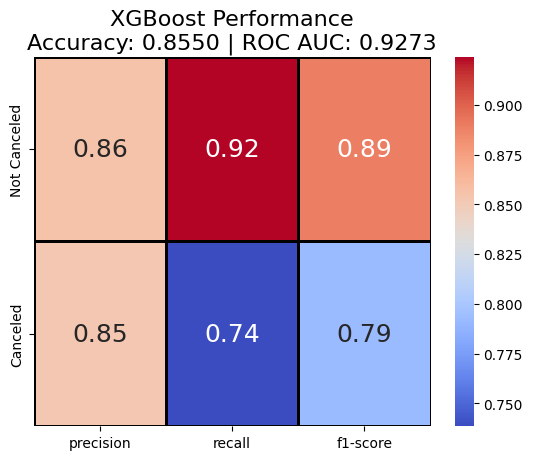

In [36]:
y_prob_xgb = best_model_xgb.predict_proba(X_test)[:, 1]
report_xgb = classification_report(y_test, y_pred_xgb, output_dict=True)
df_report_xgb = pd.DataFrame(report_xgb).T

metrics_xgb = df_report_xgb.loc[['0','1'], ['precision','recall','f1-score']]
metrics_xgb.index = ["Not Canceled", "Canceled"]

plt.figure()
sns.heatmap(metrics_xgb, annot=True,cmap = "coolwarm", fmt=".2f", annot_kws={"size":18},linewidths=2,
    linecolor="black", )

plt.title(
    f"XGBoost Performance\n"
    f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f} | "
    f"ROC AUC: {roc_auc_score(y_test, y_prob_xgb):.4f}",
    fontsize=16
)
plt.show()

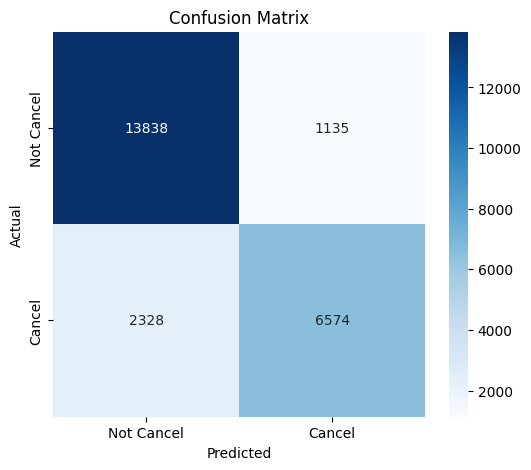

In [30]:
cm_xgb=confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6,5))
sns.heatmap(cm_xgb,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Not Cancel', 'Cancel'],
            yticklabels=['Not Cancel', 'Cancel'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

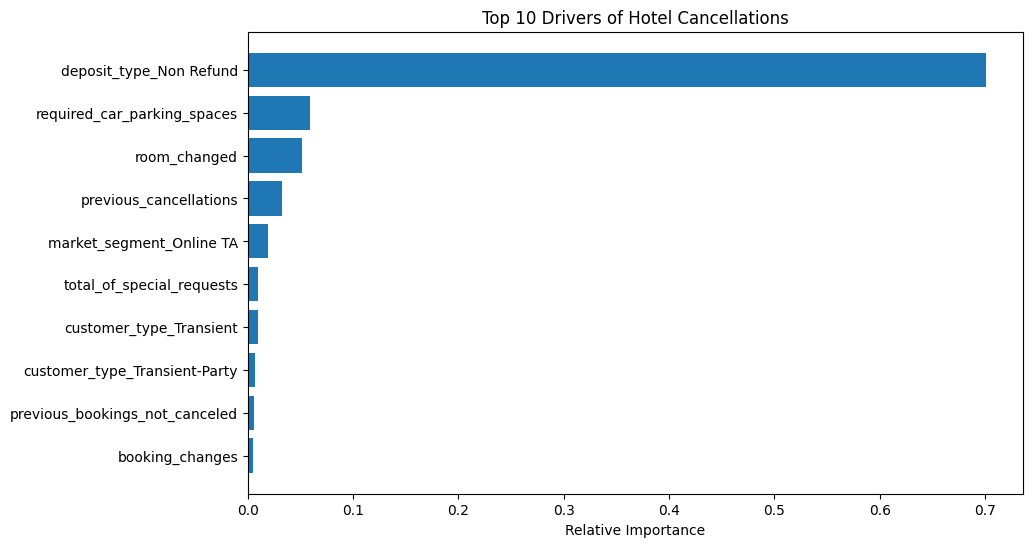

In [45]:
# Get feature importance from the best XGBoost model
importances_xgb = best_model_xgb.feature_importances_
feat_names = X_encoded.columns
indices = np.argsort(importances_xgb)[-10:] # Top 10 features

plt.figure(figsize=(10, 6))
plt.title('Top 10 Drivers of Hotel Cancellations')
plt.barh(range(len(indices)), importances_xgb[indices], align='center')
plt.yticks(range(len(indices)), [feat_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

# SHAP

In [38]:
pip install shap

In [39]:
import shap
explainer = shap.TreeExplainer(best_model_xgb)
shap_values = explainer.shap_values(X_test)

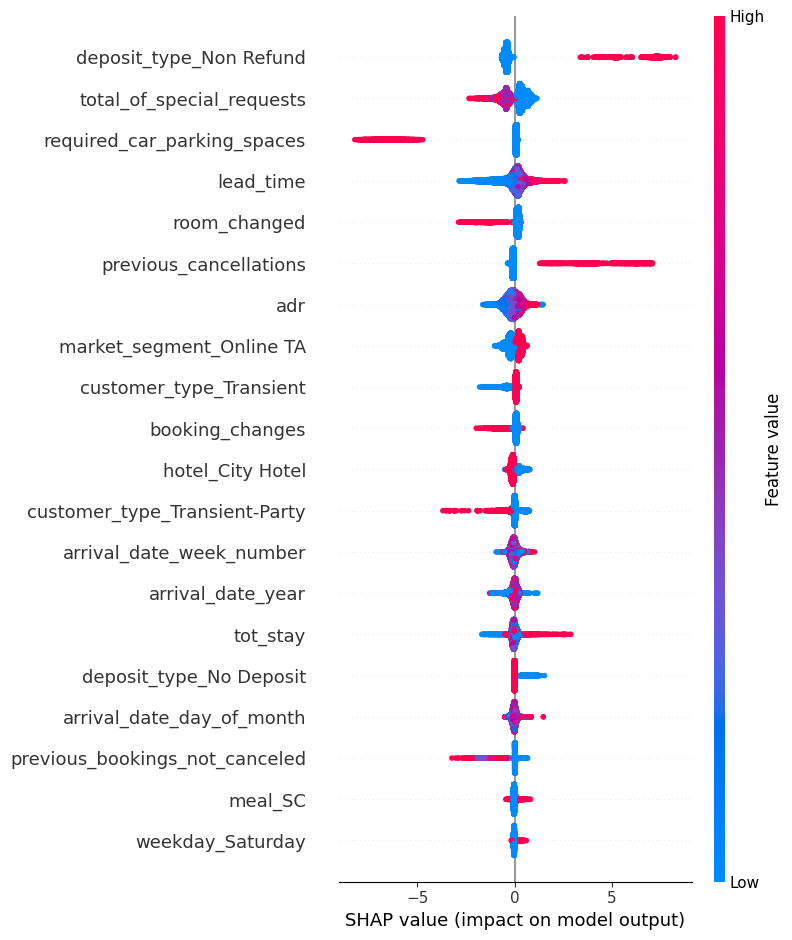

In [40]:
shap.summary_plot(shap_values, X_test)

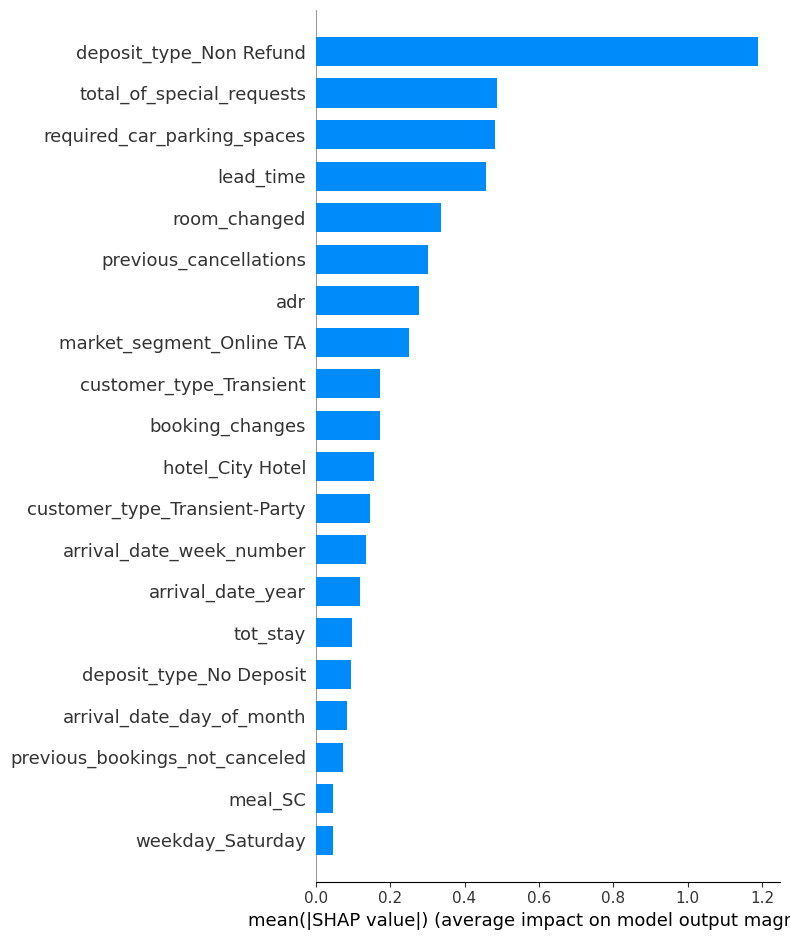

In [41]:
shap.summary_plot(shap_values, X_test, plot_type="bar")

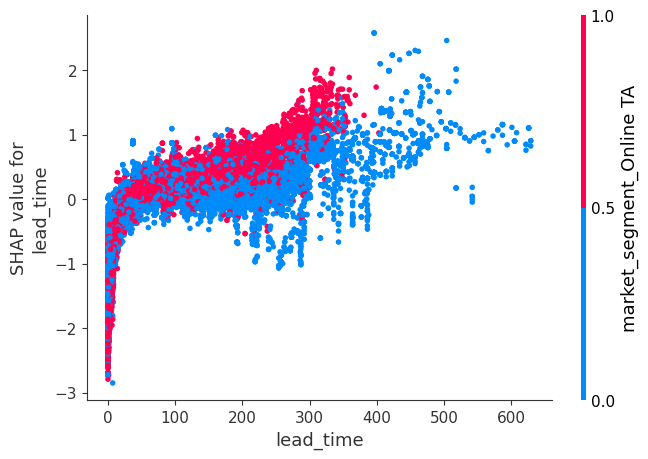

In [42]:
shap.dependence_plot("lead_time", shap_values, X_test)

In [43]:
shap.force_plot(
    explainer.expected_value,
    shap_values[10],
    X_test.iloc[10]
)